## Grid Search for Bipartite Hyperparameters

This notebook performs a grid search to find the best hyperparameters for a bipartite graph model. We will evaluate different combinations of hyperparameters and select the one that yields the best performance based on a chosen metric.

We will also compare the grid-search results to the analytical optimum derived from the contrastive-loss formulation for the bipartite hyperparameters.

In [1]:
import sys
import numpy as np

sys.path.insert(0, "domain")
sys.path.insert(0, "utils")

# hyperparameters to search over
alphas = np.linspace(0, 1, 21)  # lexical vs. positional weight (1 = lexical only)
lambdas = np.linspace(0, 1, 21)  # epsilon penalty (0 = no penalty, 1 = max penalty)
lexical_normalization_modes = [False, True]  # use global or local lexical normalization

print(f"Alpha:  {len(alphas)} values, range [{alphas[0]:.2f}, {alphas[-1]:.2f}]")
print(f"Lambda: {len(lambdas)} values, range [{lambdas[0]:.2f}, {lambdas[-1]:.2f}]")
print(f"Total combinations: {len(alphas) * len(lambdas) * len(lexical_normalization_modes):,}")

Alpha:  21 values, range [0.00, 1.00]
Lambda: 21 values, range [0.00, 1.00]
Total combinations: 882


## Load Ground Truth Annotations

In [2]:
import json
import random

# ground truth alignments (wallis dit)
with open("../experiments/hyperparameter_tuning/samples_ground_truth_alignments_wallis_dit.json", encoding="utf-8-sig") as f:
    ground_truth_entries = json.load(f)

# parse string keys to int's in ground truth alignments
for entry in ground_truth_entries:
    entry["alignment"] = {int(k): v for k, v in entry["alignment"].items()}

# deterministic 80/20 train/valid split
SPLIT_SEED = 42
VALID_FRACTION = 0.2
shuffled = list(ground_truth_entries)
random.Random(SPLIT_SEED).shuffle(shuffled)
n_valid = int(round(len(shuffled) * VALID_FRACTION))
valid_entries = shuffled[:n_valid]
train_entries = shuffled[n_valid:]

print(f"Train: {len(train_entries)} pairs")
print(f"Valid: {len(valid_entries)} pairs")

Train: 80 pairs
Valid: 20 pairs


## Imports

In [3]:
from grid_search_bipartite_hyperparameters import (
    grid_search, pivot_accuracy_grids, print_best_accuracy_summary,
)

from plot_helpers import plot_grid_search_heatmaps

## Training

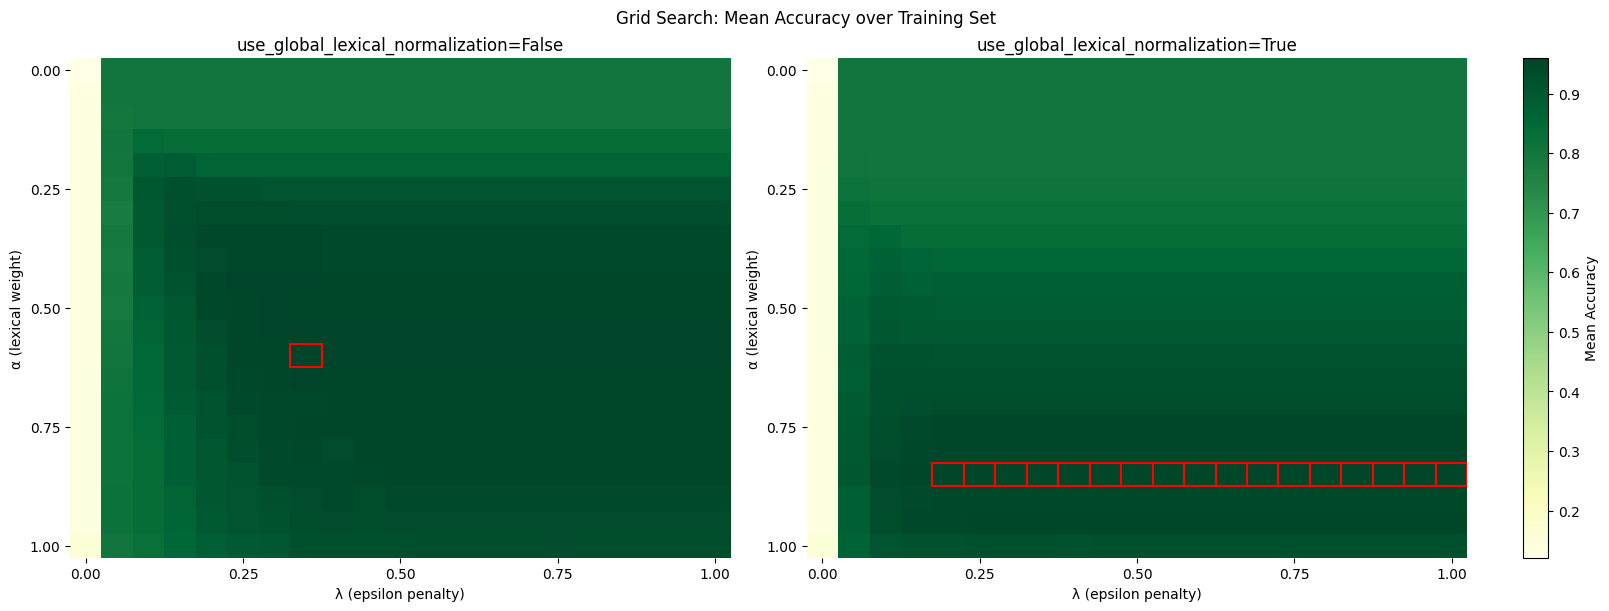

use_global_lexical_normalization=False: Best accuracy = 0.960 (1 tied)
  α tied: ['0.60']
  λ tied: ['0.35']
use_global_lexical_normalization=True: Best accuracy = 0.952 (17 tied)
  α tied: ['0.85']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [4]:
df_train = grid_search(train_entries, alphas, lambdas, lexical_normalization_modes)
train_accuracy_grids = pivot_accuracy_grids(df_train)

plot_grid_search_heatmaps(
    panels=[(train_accuracy_grids[mode], f"use_global_lexical_normalization={mode}") for mode in lexical_normalization_modes],
    alphas=alphas,
    lambdas=lambdas,
    subtitle="Grid Search: Mean Accuracy over Training Set",
)

for mode in lexical_normalization_modes:
    subset = df_train[df_train["use_global_lexical_normalization"] == mode]
    print_best_accuracy_summary(subset, f"use_global_lexical_normalization={mode}: ")